# Домашнее задание №1

## Вариант 1

<b>Цель:</b> Контроль дисперсии весов.

- Разработайте архитектуру, которая будет за <b>5 слоев</b> приводить тензор к размерности (1, 512, 1, 1).
- <b>Условие:</b> дисперсия весов третьего слоя должна быть <b>в два раза больше</b>, чем у второго и четвертого.
- <b>Эксперимент:</b> Проверьте влияние увеличенной дисперсии третьего слоя на распределение активаций после GAP и визуализируйте их гистограмму.

In [3]:
import torch

In [4]:
from torch import nn
import torch.nn.init as init
import matplotlib.pyplot as plt
import numpy as np

In [5]:
class ConvNN(nn.Module):
    
    def __init__(self):
        super().__init__() 
        # 1, 512, 1, 1: 1 batch, 512 channels, 1 x 1 (H x W) 
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, stride=1, padding=1) # (32, 32, 32)
        self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride=1, padding=1) # (64, 32, 32)
        self.conv3 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, stride=1, padding=1) # (128, 32, 32)
        self.conv4 = nn.Conv2d(in_channels = 128, out_channels = 256, kernel_size = 3, stride=1, padding=1) # (256, 32, 32)
        self.conv5 = nn.Conv2d(in_channels = 256, out_channels = 512, kernel_size = 3, stride=1, padding=1) # (512, 32, 32)
        self.relu = nn.ReLU()
        self.GAP = nn.AdaptiveAvgPool2d((1,1)) # global average pooling (512, 1, 1)
        
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.relu(x)

        x = self.conv4(x)
        x = self.relu(x)

        x = self.conv5(x)
        x = self.relu(x)

        x = self.GAP(x)
        
        return x

In [6]:
# проверка работы построенной сети 
test_tensor = torch.rand(1, 3, 32, 32) # Входной тензор, размер (1, 3, 32, 32)
convnn1 = ConvNN()
output_tensor = convnn1(test_tensor)
# размер выходного тензора
output_tensor.size()

torch.Size([1, 512, 1, 1])

In [7]:
# вторая сеть
convnn2 = ConvNN()

In [8]:
# инициализация весов 

# стратегия инициализации - He (Kaiming)
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            init.kaiming_uniform_(m.weight, nonlinearity="relu")

# стратегия инициализации - по условиям задания
def custom_weights(model):
    layer_cnt = 0
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            if layer_cnt not in [2, 3, 4]:
                init.kaiming_uniform_(m.weight, nonlinearity="relu") # инициализация всех остльных слоев
            else:
                if layer_cnt == 2 or layer_cnt == 4:
                    # инициализаируем слои 2, 3, 4 через равномерное распределение, var(X ~ U[a, b]) = (b-a)^2/12, т.к. использовали kaiming_uniform_ для других слоев
                    # предположим симетричный интервал относительно 0, например [-у , у]
                    var = 0.01 # ожидаемая дисперсия
                    y = np.sqrt(3*var) # границы интервала
                    m.weight.data.uniform_(-y, y)
                else:
                    var = 0.02 # ожидаемая дисперсия
                    y = np.sqrt(3*var) # границы интервала
                    m.weight.data.uniform_(-y, y)
        layer_cnt += 1

In [9]:
# инициализация весов моделей
initialize_weights(convnn1)
custom_weights(convnn2)

In [10]:
# проверка дисперсии весов во второй модели
for model, name in zip([convnn1, convnn2], ['He (Kaiming) инициализация', 'Инициализация по условиям']):
    
    layer2_variance = model.conv2.weight.data.var().item()
    layer3_variance = model.conv3.weight.data.var().item()
    layer4_variance = model.conv4.weight.data.var().item()
    
    print(f'Variance Check Results - {name}:')
    print('Var(layer 3) / Var(layer 2):', np.round(layer3_variance / layer2_variance, 2))
    print('Var(layer 3) / Var(layer 4):', np.round(layer3_variance / layer4_variance, 2))
    print('\n')

Variance Check Results - He (Kaiming) инициализация:
Var(layer 3) / Var(layer 2): 0.5
Var(layer 3) / Var(layer 4): 2.0


Variance Check Results - Инициализация по условиям:
Var(layer 3) / Var(layer 2): 2.0
Var(layer 3) / Var(layer 4): 2.01




In [11]:
# гистограмма распределения активаций 
def plot_activation_distributions(models, model_names = ['He (Kaiming) инициализация', 'Инициализация по условиям'], colors = ['cornflowerblue', 'thistle']):
    """Распределения активаций"""
    x = torch.randn(1, 3, 32, 32)
    outputs = []
    with torch.no_grad():
      for model in models:
        outputs.append(model(test_tensor))

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    for i, output in enumerate(outputs):
        arr = output.numpy().flatten()
        axs[i].hist(arr, bins=50, color = colors[i], edgecolor="black", linewidth = 0.7)
        axs[i].set_title(f"{model_names[i]} \nmean={arr.mean():.4f}, std={arr.std():.4f}")
        axs[i].set_xlabel("Значения")
        axs[i].set_ylabel("Частота")
        axs[i].grid(True, alpha = 0.2)
    plt.tight_layout()
    plt.show()

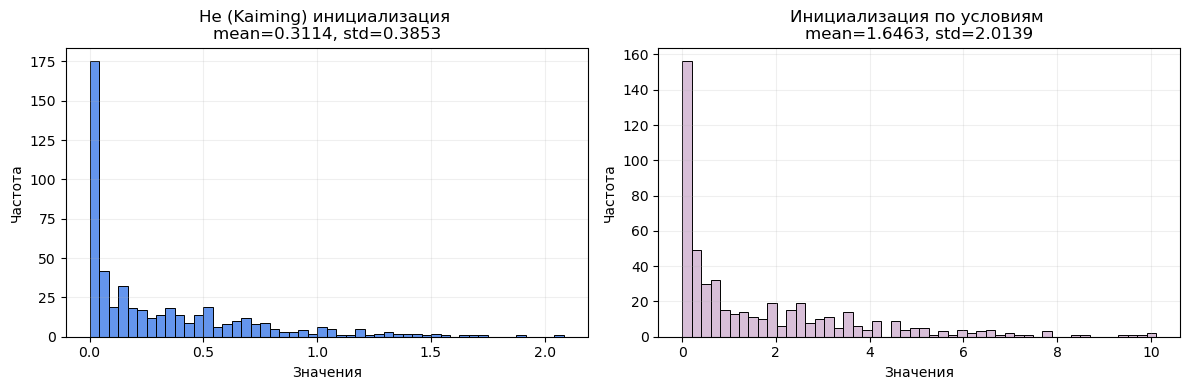

In [12]:
plot_activation_distributions([convnn1, convnn2])

В модели с слоями 2, 3, 4, которые удовлетворяют условями задачи, видно, что активации принимают большие значения, чем в модели без условий на дисперсию весов при заданных способах инициализации весов. 

## Вариант 3. Контроль количества параметров

<b>Цель:</b> Создание компактной сети.

- Создайте архитектуру, используя <b>не более 50 000 параметров.</b>
- <b>Условие:</b> Один слой должен быть <b>1x1 сверткой</b>, чтобы уменьшить число каналов.
- <b>Эксперимент:</b> Подсчитайте количество параметров каждого слоя и убедитесь, что общая сумма не превышает лимита.


Формула для подсчета количества параметров слоя:

$Parameters=(k_w \cdot k_h \cdot C_{in} +1)\cdot C_{out} $

где

$k_w $ = ширина фильтра

$k_h $ = высота фильтра

$C_{in} $ = число in_channels

$C_{out} $ = число out_channels

Здесь $ +1 $ используется для учета bias каждого фильтра.

In [16]:
class ConvNNLimitedParameters(nn.Module):
    
    def __init__(self):
        super().__init__() 
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride=1, padding=1) # число параметров (3*3*3 + 1)*16 = 448
        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, stride=1, padding=1) # (3*3*16 + 1)*32 = 4640
        self.conv3 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride=1, padding=1) # (3*3*32 + 1)*64 = 18496
        self.conv4 = nn.Conv2d(in_channels = 64, out_channels = 32, kernel_size = 3, stride=1, padding=1) # (3*3*64 + 1)*32 = 18464
        self.conv5 = nn.Conv2d(in_channels = 32, out_channels = 3, kernel_size = 1, stride=1, padding=1) # (1*1*32 + 1)*3 = 99 --> 1x1 свёрткой
        # итого 448 + 4640 + 18496 + 18464 + 99 = 42147
        self.relu = nn.ReLU()
        self.GAP = nn.AdaptiveAvgPool2d((1,1))
        
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.relu(x)

        x = self.conv4(x)
        x = self.relu(x)

        x = self.conv5(x)
        x = self.relu(x)

        x = self.GAP(x)
      
        return x

In [17]:
# проверка работы построенной сети 1
test_tensor = torch.rand(1, 3, 16, 16) 
convnn3 = ConvNNLimitedParameters()
output_tensor = convnn3(test_tensor)
# размер выходного тензора
output_tensor.size()

torch.Size([1, 3, 1, 1])

In [18]:
from prettytable import PrettyTable

# функция для подсчета параметров модели
def count_parameters(model):
    table = PrettyTable(["Слой", "Параметры"])
    total_params = 0
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        params = parameter.numel()
        table.add_row([name, params])
        total_params += params
    print(table)
    print(f"Итого: {total_params}")
    
print('Количество параметров созданной модели:')
count_parameters(convnn3)

Количество параметров созданной модели:
+--------------+-----------+
|     Слой     | Параметры |
+--------------+-----------+
| conv1.weight |    432    |
|  conv1.bias  |     16    |
| conv2.weight |    4608   |
|  conv2.bias  |     32    |
| conv3.weight |   18432   |
|  conv3.bias  |     64    |
| conv4.weight |   18432   |
|  conv4.bias  |     32    |
| conv5.weight |     96    |
|  conv5.bias  |     3     |
+--------------+-----------+
Итого: 42147


Построена сеть, которая содержить 42147 параметров. Последний слой сети является 1х1 свёрткой.